In [4]:
# X_{n+1} = e^{−1} X_n+1−e^{−2} ξ_n
import numpy as np
import pandas as pd


def simulate_ou(n_steps, gamma, dt, random_state, x0=0.0):
    """AR(1) sampled from the exact OU transition at physical step size dt."""
    rng = np.random.default_rng(random_state)
    a = np.exp(-gamma * dt)
    b = np.sqrt(1.0 - a**2)
    x = np.empty(n_steps, dtype=float)
    x[0] = float(x0)
    for t in range(n_steps - 1):
        x[t + 1] = a * x[t] + b * rng.standard_normal()
    return pd.DataFrame({"x": x})


In [2]:
# General gaussian invariant distribution: ξ_n ∼ N(0,1) for OU, not actually used for this figure
# Actual density used is below
def stationary_density(x, theta=1.0, mu=0.0, sigma=1.0):
    var = sigma**2 / (2 * theta)
    return np.exp(-((x - mu) ** 2) / (2 * var)) / np.sqrt(2 * np.pi * var)


In [7]:
# OU specific normalisation constant

from kooplearn._linalg import weighted_norm


def ou_normalisation(functions, x, density):
    #    abs2 = np.abs(functions) ** 2
    #    norms = np.sqrt(np.trapezoid(abs2 * density[:, None], x[:, 0], axis=0))
    W = np.diag(density.reshape(-1))
    norms = weighted_norm(functions, W)
    norms = np.maximum(norms, 1e-12)
    functions = functions / norms
    return functions


In [ ]:
# Some reused variables
from kooplearn.preprocessing import FeatureFlattener

gamma = 1.0

x = np.linspace(-4, 4, 1025)[:, None]

flattener = FeatureFlattener()
x_flat = flattener.fit_transform(x)

# This is the exact density used in the paper for OU
density = np.exp(-0.5 * x_flat**2) / np.sqrt(2 * np.pi)


100%|██████████| 10/10 [00:16<00:00,  1.69s/it]


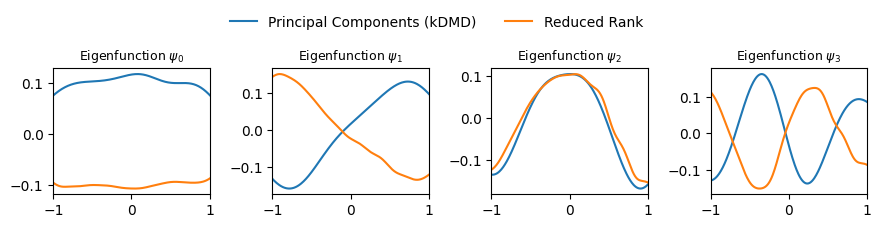

In [8]:
# First, Fig. 2 but with OU

from collections import defaultdict

import matplotlib.pyplot as plt
from tqdm import tqdm

from kooplearn.kernel import KernelRidge


def fit_and_estimate(reduced_rank, x, density, random_state):
    # Substitute Langevin with OU

    data = simulate_ou(n_steps=n_steps, gamma=gamma, dt=dt, random_state=0, x0=0.0)
    data = data.iloc[::subsample][:n_train]

    # Model definition, same as fig 2 for now
    model = KernelRidge(
        n_components=5,
        reduced_rank=reduced_rank,
        gamma=12.5,
        kernel="rbf",
        alpha=1e-6,
        random_state=random_state,
    )

    # Fit and estimate eigenfunctions
    model.fit(data)  # fit transfer op model
    values, functions = model.eig(
        eval_right_on=x
    )  # (right) eigenvalue estimation, evaluate on array x
    sort_perm = np.flip(np.argsort(np.abs(values)))  # Order decreasingly
    values, functions = values[sort_perm], functions[:, sort_perm]
    functions = ou_normalisation(functions, x, density)
    return functions


# Run functions for both RRR (reduced rank) and kDMD (full rank) estimators
dt = 1e-4
n_repetitions = 10
results = defaultdict(list)
for method, reduced_rank in zip(["Principal Components (kDMD)", "Reduced Rank"], [False, True]):
    for i in tqdm(range(n_repetitions)):
        results[method].append(fit_and_estimate(reduced_rank, x, density, i))

# Print results
fig, axs = plt.subplots(ncols=4, figsize=(9, 2))
for fun_id, ax in enumerate(axs):
    for method, functions in results.items():
        color = "tab:blue" if "Principal" in method else "tab:orange"
        ax.plot(x, functions[0][:, fun_id], color=color, label=method)
    ax.set_title(rf"Eigenfunction $\psi_{fun_id}$", fontsize=9)
    ax.set_xlim(-1, 1)
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncols=2,
    frameon=False,
    bbox_to_anchor=(0.0, 1.05, 1.0, 0.102),
)
plt.tight_layout()
plt.show()


## Figure 1 reproduction
### Kernel family
$$k_{\Pi,\nu}(x,x')=\sum_{i\in\mathbb N}\mu_{\Pi(i)}^{2\nu} f_i(x)f_i(x')$$

#### Trial run to test plotting

ugly-PCR:   0%|          | 0/5 [00:00<?, ?it/s]/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 1 dimensions of the 3 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 4.894e-15.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
ugly-PCR:  20%|██        | 1/5 [00:17<01:10, 17.58s/it]/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 1 dimensions of the 3 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 4.916e-15.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
ugly-PCR:  40%|████      | 2/5 [00:37<00:57, 19.07s/it]/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 1 dimensions of the 3 requested due to numeric

('good', 'PCR') (5, 3)
('good', 'RRR') (5, 3)
('bad', 'PCR') (5, 3)
('bad', 'RRR') (5, 3)
('ugly', 'PCR') (5, 3)
('ugly', 'RRR') (5, 3)


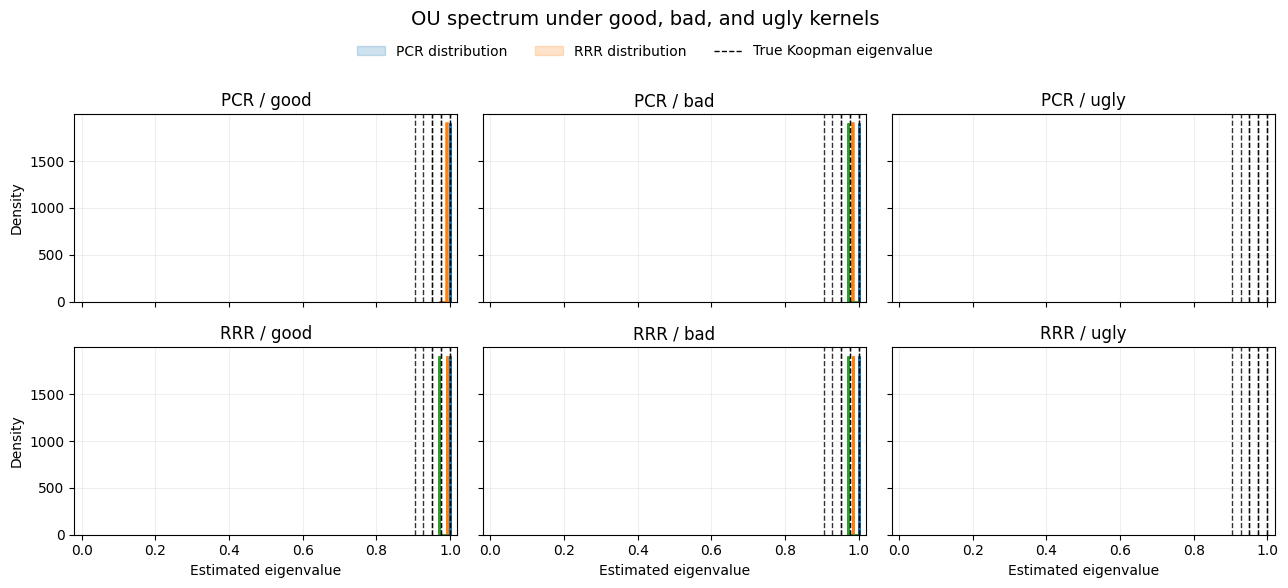

In [ ]:
# Spectral rates paper fig. 1-style eigenfunction comparison:
# - 3 columns = good / bad / ugly kernels
# - overlay PCR (blue) and RRR (orange)
# - show mean estimated eigenfunction across trials for the first few modes

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from tqdm import tqdm


# ----------------------------------------------------------------------------------------------
# Hermite helpers / kernel family - in line with Kostic et al. Kernel construction in Example 3
# ----------------------------------------------------------------------------------------------
def hermite_features(x, M):
    """Normalized probabilists' Hermite functions f_n = He_n/sqrt(n!),
    via sqrt(n) f_n = x f_{n-1} - sqrt(n-1) f_{n-2}. No factorial, no hermeval."""
    x = np.asarray(x).reshape(-1)
    f = np.empty((x.shape[0], M))
    f[:, 0] = 1.0
    if M > 1:
        f[:, 1] = x
    for n in range(2, M):
        f[:, n] = (x * f[:, n - 1] - np.sqrt(n - 1) * f[:, n - 2]) / np.sqrt(n)
    return f


def hermite_kernel(kind, r, M):
    w = kernel_weights(kind, r, M)
    cache = {}

    def get_features(x):
        key = np.asarray(x).ravel().tobytes()
        feats = cache.get(key)
        if feats is None:
            feats = hermite_features(x, M)[0]
            cache[key] = feats
        return feats

    def kernel(x, y):
        fx, fy = get_features(x), get_features(y)
        return float(np.sum(w * fx * fy))

    return kernel


def kernel_permutation(kind, r, M):
    pi = np.arange(M)

    if kind == "good":
        return pi

    if kind == "bad":
        if 2 * r > M:
            raise ValueError(f"Need M >= 2*r for bad kernel, got M={M}, r={r}")
        pi2 = pi.copy()
        a = np.arange(r)
        b = np.arange(r, 2 * r)
        pi2[a] = b[::-1]
        pi2[b] = a[::-1]
        return pi2

    if kind == "ugly":
        return pi[::-1]

    raise ValueError(kind)


def kernel_weights(kind, r, M):
    mu = np.exp(-np.arange(M))
    nu = 1.0 if kind == "good" else (1.0 / (r**2) if kind == "bad" else r**2)
    pi = kernel_permutation(kind, r, M)
    return mu[pi] ** (2.0 * nu)


# -----------------------------
# OU reference eigenfunctions
# -----------------------------
def compute_ou_eig(gamma, lag, num_components):
    n = np.arange(num_components)
    return np.exp(-n * gamma * lag)


# -----------------------------
# Sign-align estimated functions to a reference
# -----------------------------
def standardize_sign(eigenfunction, reference, x):
    eigenfunction_cut = cut_functions_to_domain(eigenfunction, x)
    reference_cut = cut_functions_to_domain(reference, x)
    norm_p = np.linalg.norm(eigenfunction_cut + reference_cut)
    norm_m = np.linalg.norm(eigenfunction_cut - reference_cut)
    if norm_p <= norm_m:
        return -1.0 * eigenfunction
    else:
        return eigenfunction


def cut_functions_to_domain(functions, x, x_lims=(-1, 1)):
    mask = (x >= x_lims[0]) & (x <= x_lims[1])
    return functions[mask]


# -----------------------------
# Parameters
# -----------------------------
kernels = ["good", "bad", "ugly"]
methods = [("PCR", False), ("RRR", True)]

n_train = 1000
subsample = 50
n_steps = n_train * subsample
n_trials = 5  # increase toward paper settings for smoother curves
n_show = 3  # number of leading eigenfunctions to plot
M = 10  # kernel truncation level
dt = 1e-4
lag = dt * subsample * 5
n_components = 5
r = n_show
true_eigs = compute_ou_eig(gamma, lag, n_components)

x_plot = x.reshape(-1)

results = defaultdict(list)


# -----------------------------
# Fit model and return eigenvalues
# -----------------------------
def fit_and_estimate_values(reduced_rank, x, density, random_state, kind, M, n_show):
    out = np.full(n_show, np.nan, dtype=float)

    try:
        data = simulate_ou(
            n_steps=n_steps,
            gamma=gamma,
            dt=dt,
            random_state=random_state,
            x0=0.0,
        )
        data = data.iloc[::subsample]
        data = data[:n_train]

        if random_state < 2:
            tqdm.write(
                f"{kind}-{reduced_rank}-trial {random_state}: {data.head().to_numpy().ravel()[:5]}"
            )

        model = KernelRidge(
            n_components=n_show,
            reduced_rank=reduced_rank,
            kernel=hermite_kernel(kind, r, M),
            alpha=0,
            random_state=random_state,
        )

        model.fit(data)
        values, functions = model.eig(eval_right_on=x)

        values = np.asarray(values)
        values = np.real_if_close(values)
        values = np.real(values)

        if values.ndim == 0:
            values = np.array([float(values)])

        sort_perm = np.flip(np.argsort(np.abs(values)))
        values = values[sort_perm]

        k = min(n_show, len(values))
        out[:k] = values[:k]

    except Exception as e:
        tqdm.write(f"trial {random_state} failed: {e}")

    return out


# -----------------------------
# Collect spectra
# -----------------------------
results = defaultdict(list)

for kind in kernels:
    for method, reduced_rank in methods:
        for trial in tqdm(range(n_trials), desc=f"{kind}-{method}"):
            vals = fit_and_estimate_values(
                reduced_rank=reduced_rank,
                x=x,
                density=density,
                random_state=trial,
                kind=kind,
                M=M,
                n_show=n_show,
            )
            results[(kind, method)].append(vals)

for key in results:
    results[key] = np.asarray(results[key], dtype=float)
    print(key, results[key].shape)

# -----------------------------
# Plot
# -----------------------------
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13.0, 5.5),
    sharex=True,
    sharey=True,
)

colors = {"PCR": "tab:blue", "RRR": "tab:orange"}
bins = np.linspace(0.97, 1.001, 60)

for row, (method, _) in enumerate(methods):
    for col, kind in enumerate(kernels):
        ax = axs[row, col]
        vals = results[(kind, method)]

        for m in range(n_show):
            vm = vals[:, m]
            vm = vm[np.isfinite(vm)]
            if vm.size == 0:
                continue

            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="step",
                lw=1.8,
                label=f"mode {m + 1}" if (row == 0 and col == 0) else None,
            )

        for ev in true_eigs[:n_show]:
            ax.axvline(float(ev), color="black", ls="--", lw=1.0, alpha=0.8)

        ax.set_title(f"{method} / {kind}", fontsize=12)
        ax.set_xlim(0.97, 1.001)
        ax.grid(alpha=0.20)

        # true Koopman eigenvalue lines
        for ev in true_eigs:
            ax.axvline(ev, color="black", ls="--", lw=1.0, alpha=0.8)

        ax.set_title(f"{method} / {kind}", fontsize=12)
        ax.set_xlim(-0.02, 1.02)
        ax.grid(alpha=0.20)

        if col == 0:
            ax.set_ylabel("Density")

for ax in axs[-1, :]:
    ax.set_xlabel("Estimated eigenvalue")

# compact legend

legend_handles = [
    Patch(facecolor="tab:blue", edgecolor="tab:blue", alpha=0.22, label="PCR distribution"),
    Patch(facecolor="tab:orange", edgecolor="tab:orange", alpha=0.22, label="RRR distribution"),
    Line2D([0], [0], color="black", lw=1.0, ls="--", label="True Koopman eigenvalue"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "OU spectrum under good, bad, and ugly kernels",
    fontsize=14,
    y=1.06,
)

plt.tight_layout()
plt.show()


#### Inspecting returned numbers to determine best plotting approach

In [ ]:
print(kind, method, "min/max per mode:")
print(np.nanmin(vals, axis=0), np.nanmax(vals, axis=0))
print("finite counts:", np.sum(np.isfinite(vals), axis=0))


for key, arr in results.items():
    print(key)
    print(arr)


ugly RRR min/max per mode:
[ 1.91157397e+00  9.42242619e-01 -6.74103418e-08] [1.91175194e+00 9.42313337e-01 1.29128988e-07]
finite counts: [5 5 5]
('good', 'PCR')
[[0.99999996 0.99019265 0.96763651]
 [0.99999996 0.99019265 0.96763651]
 [0.99999996 0.99019265 0.96763651]
 [0.99999996 0.99019265 0.96763651]
 [0.99999996 0.99019265 0.96763651]]
('good', 'RRR')
[[1.00000132 0.99057766 0.97038156]
 [1.00000064 0.99060487 0.97036146]
 [1.0000001  0.99058829 0.97037559]
 [1.00000267 0.99062207 0.97033995]
 [1.00000011 0.99066317 0.97029918]]
('bad', 'PCR')
[[0.99956225 0.98307248 0.97081843]
 [0.99956225 0.98307248 0.97081843]
 [0.99956225 0.98307248 0.97081843]
 [0.99956225 0.98307248 0.97081843]
 [0.99956225 0.98307248 0.97081843]]
('bad', 'RRR')
[[0.99973425 0.98495391 0.97169111]
 [0.9997779  0.98494277 0.97166086]
 [0.99978692 0.98493578 0.97166029]
 [0.99975151 0.98490444 0.97172386]
 [0.99973369 0.98495793 0.97168608]]
('ugly', 'PCR')
[[0.9558193  0.94227088        nan]
 [0.9558193  0.

#### Alternative plotting 

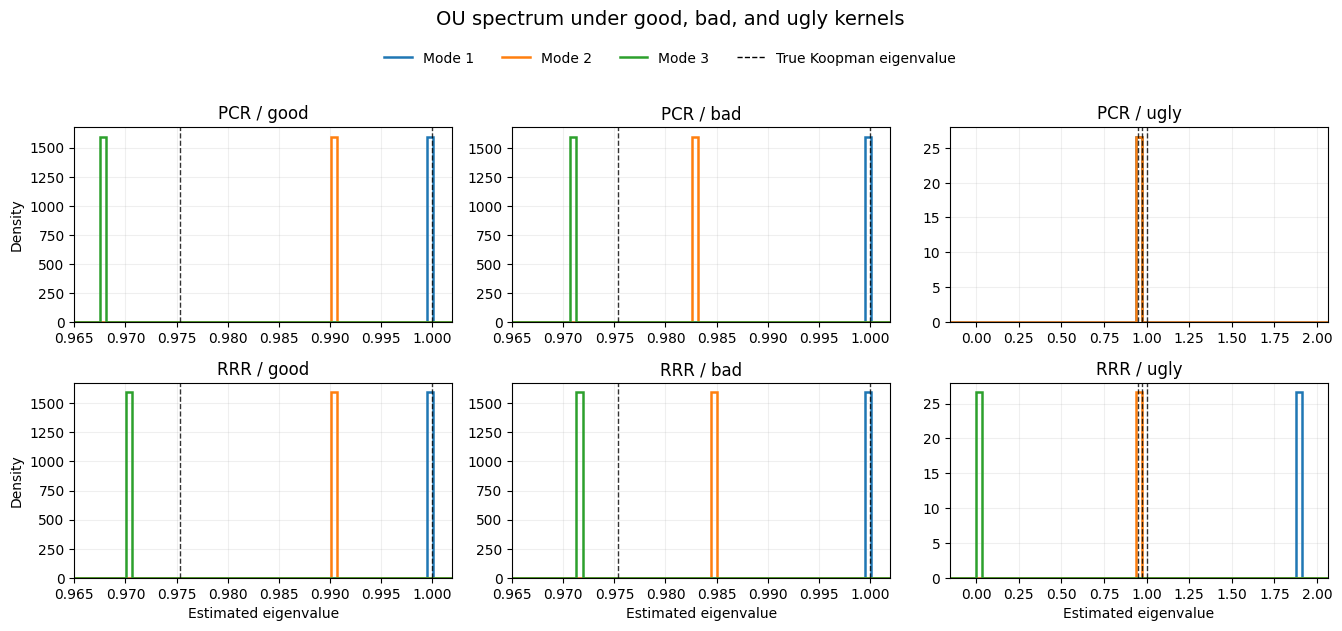

In [16]:
# -----------------------------
# Plot
# -----------------------------

# Compute one x-range per kernel, shared across PCR/RRR rows in that column
kernel_ranges = {}
for kind in kernels:
    combined = []
    for method, _ in methods:
        arr = np.asarray(results[(kind, method)], dtype=float)
        combined.append(arr[np.isfinite(arr)])
    combined = np.concatenate(combined)

    if combined.size == 0:
        kernel_ranges[kind] = (0.0, 1.0)
        continue

    if kind in ("good", "bad"):
        xlo = min(0.965, np.nanmin(combined) - 0.002)
        xhi = max(1.002, np.nanmax(combined) + 0.002)
    else:
        span = np.nanmax(combined) - np.nanmin(combined)
        pad = max(0.03, 0.08 * span if span > 0 else 0.05)
        xlo = np.nanmin(combined) - pad
        xhi = np.nanmax(combined) + pad

    kernel_ranges[kind] = (xlo, xhi)

fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13.5, 5.8),
    sharex=False,
    sharey=False,
)

mode_colors = ["tab:blue", "tab:orange", "tab:green"]

for row, (method, _) in enumerate(methods):
    for col, kind in enumerate(kernels):
        ax = axs[row, col]
        vals = np.asarray(results[(kind, method)], dtype=float)  # shape (n_trials, n_show)

        xlo, xhi = kernel_ranges[kind]
        bins = np.linspace(xlo, xhi, 60)

        # plot mode-wise empirical distributions
        for m in range(min(n_show, vals.shape[1])):
            vm = vals[:, m]
            vm = vm[np.isfinite(vm)]
            if vm.size == 0:
                continue

            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="step",
                lw=1.8,
                color=mode_colors[m % len(mode_colors)],
                label=f"Mode {m + 1}" if (row == 0 and col == 0) else None,
            )

        # true Koopman eigenvalue lines, only if visible in this panel
        for j, ev in enumerate(true_eigs[:n_show]):
            if xlo <= ev <= xhi:
                ax.axvline(
                    float(ev),
                    color="black",
                    ls="--",
                    lw=1.0,
                    alpha=0.8,
                    label="True Koopman eigenvalue" if (row == 0 and col == 0 and j == 0) else None,
                )

        ax.set_title(f"{method} / {kind}", fontsize=12)
        ax.set_xlim(xlo, xhi)
        ax.grid(alpha=0.20)

        if col == 0:
            ax.set_ylabel("Density")
        if row == len(methods) - 1:
            ax.set_xlabel("Estimated eigenvalue")

legend_handles = [
    Line2D([0], [0], color="tab:blue", lw=1.8, label="Mode 1"),
    Line2D([0], [0], color="tab:orange", lw=1.8, label="Mode 2"),
    Line2D([0], [0], color="tab:green", lw=1.8, label="Mode 3"),
    Line2D([0], [0], color="black", lw=1.0, ls="--", label="True Koopman eigenvalue"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.03),
)

fig.suptitle(
    "OU spectrum under good, bad, and ugly kernels",
    fontsize=14,
    y=1.08,
)

plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# Fit model and return eigenvalues
# -----------------------------
alpha = 1e-10

def fit_and_estimate_values(reduced_rank, x, density, random_state, kind, M, n_show):
    out = np.full(n_show, np.nan, dtype=float)
    method_name = "RRR" if reduced_rank else "PCR"
    local_n_show = 2 if (kind == "ugly" and method_name == "RRR") else n_show

    try:
        data = simulate_ou(
            n_steps=n_steps,
            gamma=gamma,
            dt=dt,
            random_state=random_state,
            x0=0.0,
        )
        data = data.iloc[::subsample]
        data = data[:n_train]

        model = KernelRidge(
            n_components=local_n_show,
            reduced_rank=reduced_rank,
            kernel=hermite_kernel(kind, r, M),
            alpha=alpha,
            random_state=random_state,
        )

        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            model.fit(data)
            values, functions = model.eig(eval_right_on=x)

        for w in caught:
            tqdm.write(
                f"WARNING [{kind}/{method_name}/trial {random_state}] "
                f"{w.category.__name__}: {w.message}"
            )

        values = np.asarray(values)
        values = np.real_if_close(values)
        values = np.real(values)

        if values.ndim == 0:
            values = np.array([float(values)])

        sort_perm = np.flip(np.argsort(np.abs(values)))
        values = values[sort_perm]

        k = min(n_show, len(values))
        out[:k] = values[:k]

    except Exception as e:
        tqdm.write(f"FAILED [{kind}/{method_name}/trial {random_state}] {e}")

    return out


for kind in kernels:
    for method, reduced_rank in methods:
        for trial in tqdm(range(n_trials), desc=f"{kind}-{method}"):
            vals = fit_and_estimate_values(
                reduced_rank=reduced_rank,
                x=x,
                density=density,
                random_state=trial,
                kind=kind,
                M=M,
                n_show=n_show,
            )


good-PCR:  20%|██        | 1/5 [00:25<01:41, 25.38s/it]

0 [0.         0.09133466 0.11428814 0.13269893 0.04181287]


good-PCR:  40%|████      | 2/5 [00:43<01:03, 21.17s/it]

1 [ 0.         -0.02552024 -0.10379688 -0.17162876 -0.2065348 ]


good-PCR:  60%|██████    | 3/5 [01:01<00:39, 19.76s/it]

...

2 [ 0.          0.01551493 -0.01211123  0.04026554 -0.02222843]


ugly-RRR:  80%|████████  | 4/5 [01:20<00:19, 19.57s/it]

3 [ 0.          0.01763971 -0.08700411  0.012707    0.1368871 ]


ugly-RRR: 100%|██████████| 5/5 [01:39<00:00, 19.87s/it]

4 [ 0.         -0.06556221 -0.08903661  0.07738431  0.13540951]


#### Combined fixes

ugly-RRR:  90%|█████████ | 18/20 [25:03<02:31, 75.78s/it]

WARNING [ugly/RRR/trial 17] UserWarning: Warning: Discarded 1 dimensions of the 2 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 3.722e-07.


ugly-RRR: 100%|██████████| 20/20 [27:28<00:00, 82.44s/it]


('good', 'PCR') (20, 3)
('good', 'RRR') (20, 3)
('bad', 'PCR') (20, 3)
('bad', 'RRR') (20, 3)
('ugly', 'PCR') (20, 3)
('ugly', 'RRR') (20, 3)


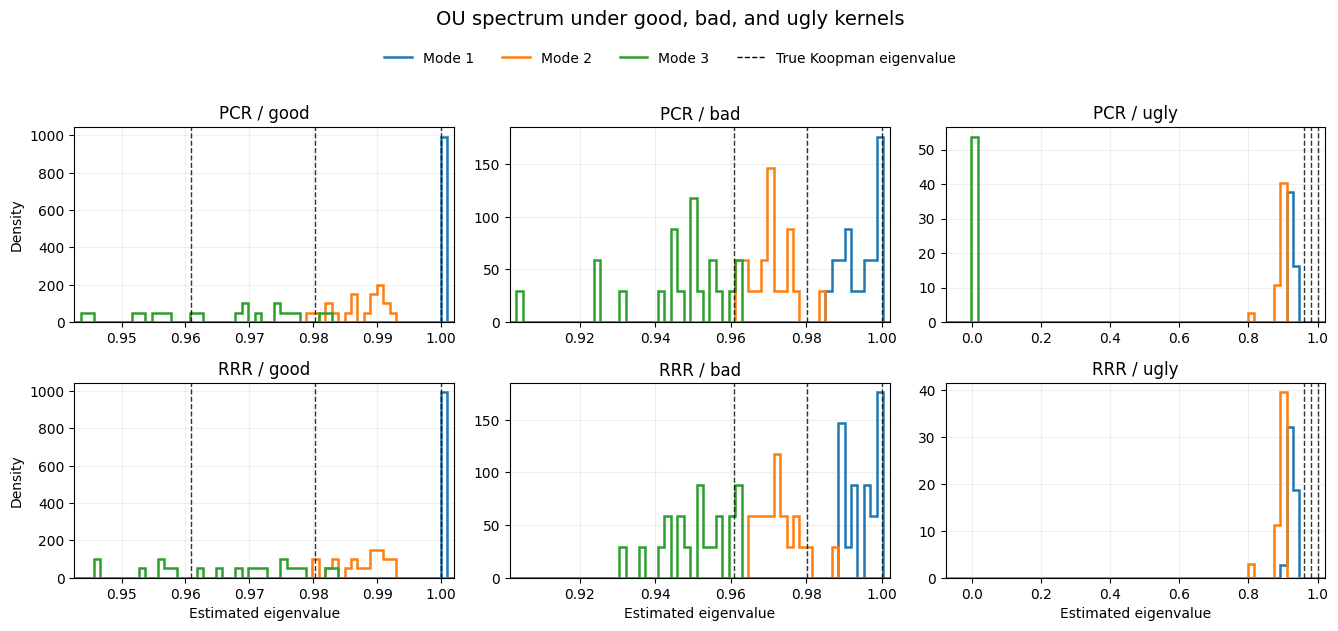

In [ ]:
import warnings
from collections import Counter

# -----------------------------
# Parameters
# -----------------------------
kernels = ["good", "bad", "ugly"]
methods = [("PCR", False), ("RRR", True)]

n_train = 2000
subsample = 100
n_steps = n_train * subsample
n_trials = 20  # increase = smoother curves
n_show = 3  # number of leading eigenfunctions to plot
M = 10  # kernel truncation level
dt = 1e-4
lag = dt * subsample * 2
n_components = 5
r = n_show
true_eigs = compute_ou_eig(gamma, lag, n_components)

x_plot = x.reshape(-1)

results = defaultdict(list)


# -----------------------------
# Fit model and return eigenvalues
# -----------------------------


warning_log = []


alpha = 1e-11


def fit_and_estimate_values(reduced_rank, x, density, random_state, kind, M, n_show):
    out = np.full(n_show, np.nan, dtype=float)
    method_name = "RRR" if reduced_rank else "PCR"
    local_n_show = 2 if (kind == "ugly" and method_name == "RRR") else n_show

    try:
        data = simulate_ou(
            n_steps=n_steps,
            gamma=gamma,
            dt=dt,
            random_state=random_state,
            x0=0.0,
        )
        data = data.iloc[::subsample]
        data = data[:n_train]

        model = KernelRidge(
            n_components=local_n_show,
            reduced_rank=reduced_rank,
            kernel=hermite_kernel(kind, r, M),
            alpha=alpha,
            random_state=random_state,
        )

        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            model.fit(data)
            values, functions = model.eig(eval_right_on=x)

        for w in caught:
            tqdm.write(
                f"WARNING [{kind}/{method_name}/trial {random_state}] "
                f"{w.category.__name__}: {w.message}"
            )

        values = np.asarray(values)
        values = np.real_if_close(values)
        values = np.real(values)

        if values.ndim == 0:
            values = np.array([float(values)])

        sort_perm = np.flip(np.argsort(np.abs(values)))
        values = values[sort_perm]

        k = min(n_show, len(values))
        out[:k] = values[:k]

    except Exception as e:
        tqdm.write(f"FAILED [{kind}/{method_name}/trial {random_state}] {e}")

    return out


# -----------------------------
# Collect spectra
# -----------------------------
results = defaultdict(list)


for kind in kernels:
    for method, reduced_rank in methods:
        for trial in tqdm(range(n_trials), desc=f"{kind}-{method}"):
            vals = fit_and_estimate_values(
                reduced_rank=reduced_rank,
                x=x,
                density=density,
                random_state=trial,
                kind=kind,
                M=M,
                n_show=n_show,
            )
            results[(kind, method)].append(vals)

for key in results:
    results[key] = np.asarray(results[key], dtype=float)
    print(key, results[key].shape)

summary = Counter((w["kind"], w["method"], w["warning_type"], w["message"]) for w in warning_log)

for key, count in summary.items():
    print(count, key)

# -----------------------------
# Plot
# -----------------------------

# Compute one x-range per kernel, shared across PCR/RRR rows in that column
kernel_ranges = {}
for kind in kernels:
    combined = []
    for method, _ in methods:
        arr = np.asarray(results[(kind, method)], dtype=float)
        combined.append(arr[np.isfinite(arr)])
    combined = np.concatenate(combined)

    if combined.size == 0:
        kernel_ranges[kind] = (0.0, 1.0)
        continue

    if kind in ("good", "bad"):
        xlo = min(0.965, np.nanmin(combined) - 0.002)
        xhi = max(1.002, np.nanmax(combined) + 0.002)
    else:
        span = np.nanmax(combined) - np.nanmin(combined)
        pad = max(0.03, 0.08 * span if span > 0 else 0.05)
        xlo = np.nanmin(combined) - pad
        xhi = np.nanmax(combined) + pad

    kernel_ranges[kind] = (xlo, xhi)

fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13.5, 5.8),
    sharex=False,
    sharey=False,
)

mode_colors = ["tab:blue", "tab:orange", "tab:green"]

for row, (method, _) in enumerate(methods):
    for col, kind in enumerate(kernels):
        ax = axs[row, col]
        vals = np.asarray(results[(kind, method)], dtype=float)  # shape (n_trials, n_show)

        xlo, xhi = kernel_ranges[kind]
        bins = np.linspace(xlo, xhi, 60)

        # plot mode-wise empirical distributions
        for m in range(min(n_show, vals.shape[1])):
            vm = vals[:, m]
            vm = vm[np.isfinite(vm)]
            if vm.size == 0:
                continue

            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="step",
                lw=1.8,
                color=mode_colors[m % len(mode_colors)],
                label=f"Mode {m + 1}" if (row == 0 and col == 0) else None,
            )

        # true Koopman eigenvalue lines, only if visible in this panel
        for j, ev in enumerate(true_eigs[:n_show]):
            if xlo <= ev <= xhi:
                ax.axvline(
                    float(ev),
                    color="black",
                    ls="--",
                    lw=1.0,
                    alpha=0.8,
                    label="True Koopman eigenvalue" if (row == 0 and col == 0 and j == 0) else None,
                )

        ax.set_title(f"{method} / {kind}", fontsize=12)
        ax.set_xlim(xlo, xhi)
        ax.grid(alpha=0.20)

        if col == 0:
            ax.set_ylabel("Density")
        if row == len(methods) - 1:
            ax.set_xlabel("Estimated eigenvalue")

legend_handles = [
    Line2D([0], [0], color="tab:blue", lw=1.8, label="Mode 1"),
    Line2D([0], [0], color="tab:orange", lw=1.8, label="Mode 2"),
    Line2D([0], [0], color="tab:green", lw=1.8, label="Mode 3"),
    Line2D([0], [0], color="black", lw=1.0, ls="--", label="True Koopman eigenvalue"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.03),
)

# -----------------------------
# Plot
# -----------------------------

# Compute one x-range per kernel, shared across PCR/RRR rows in that column
kernel_ranges = {}
for kind in kernels:
    combined = []
    for method, _ in methods:
        arr = np.asarray(results[(kind, method)], dtype=float)
        combined.append(arr[np.isfinite(arr)])
    combined = np.concatenate(combined)

    if combined.size == 0:
        kernel_ranges[kind] = (0.0, 1.0)
        continue

    if kind in ("good", "bad"):
        xlo = min(0.965, np.nanmin(combined) - 0.002)
        xhi = max(1.002, np.nanmax(combined) + 0.002)
    else:
        span = np.nanmax(combined) - np.nanmin(combined)
        pad = max(0.03, 0.08 * span if span > 0 else 0.05)
        xlo = np.nanmin(combined) - pad
        xhi = np.nanmax(combined) + pad

    kernel_ranges[kind] = (xlo, xhi)

fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13.5, 5.8),
    sharex=False,
    sharey=False,
)

mode_colors = ["tab:blue", "tab:orange", "tab:green"]

for row, (method, _) in enumerate(methods):
    for col, kind in enumerate(kernels):
        ax = axs[row, col]
        vals = np.asarray(results[(kind, method)], dtype=float)  # shape (n_trials, n_show)

        xlo, xhi = kernel_ranges[kind]
        bins = np.linspace(xlo, xhi, 60)

        # plot mode-wise empirical distributions
        for m in range(min(n_show, vals.shape[1])):
            vm = vals[:, m]
            vm = vm[np.isfinite(vm)]
            if vm.size == 0:
                continue

            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="step",
                lw=1.8,
                color=mode_colors[m % len(mode_colors)],
                label=f"Mode {m + 1}" if (row == 0 and col == 0) else None,
            )

        # true Koopman eigenvalue lines, only if visible in this panel
        for j, ev in enumerate(true_eigs[:n_show]):
            if xlo <= ev <= xhi:
                ax.axvline(
                    float(ev),
                    color="black",
                    ls="--",
                    lw=1.0,
                    alpha=0.8,
                    label="True Koopman eigenvalue" if (row == 0 and col == 0 and j == 0) else None,
                )

        ax.set_title(f"{method} / {kind}", fontsize=12)
        ax.set_xlim(xlo, xhi)
        ax.grid(alpha=0.20)

        if col == 0:
            ax.set_ylabel("Density")
        if row == len(methods) - 1:
            ax.set_xlabel("Estimated eigenvalue")

legend_handles = [
    Line2D([0], [0], color="tab:blue", lw=1.8, label="Mode 1"),
    Line2D([0], [0], color="tab:orange", lw=1.8, label="Mode 2"),
    Line2D([0], [0], color="tab:green", lw=1.8, label="Mode 3"),
    Line2D([0], [0], color="black", lw=1.0, ls="--", label="True Koopman eigenvalue"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.03),
)

fig.suptitle(
    "OU spectrum under good, bad, and ugly kernels",
    fontsize=14,
    y=1.08,
)

plt.tight_layout()
plt.show()


fig.suptitle(
    "OU spectrum under good, bad, and ugly kernels",
    fontsize=14,
    y=1.08,
)

plt.tight_layout()
plt.show()


In [20]:
for key, arr in results.items():
    print(key, np.std(arr, axis=0))


('good', 'PCR') [8.76172498e-08 3.81960582e-03 1.13401510e-02]
('good', 'RRR') [9.97358492e-06 3.79564305e-03 1.10472474e-02]
('bad', 'PCR') [0.00459123 0.00533743 0.0141217 ]
('bad', 'RRR') [0.00401719 0.00531422 0.00881906]
('ugly', 'PCR') [0.03113919 0.02808623        nan]
('ugly', 'RRR') [0.27846931        nan        nan]


ugly-RRR: 100%|██████████| 50/50 [00:00<00:00, 532272.08it/s]

('good', 'PCR') [nan nan nan]
('good', 'RRR') [nan nan nan]
('bad', 'PCR') [nan nan nan]
('bad', 'RRR') [nan nan nan]
('ugly', 'PCR') [nan nan nan]
('ugly', 'RRR') [nan nan nan]



/var/folders/kn/wt7515611bs7kl6jz_k60df40000gn/T/ipykernel_35477/140007749.py:195: RuntimeWarning: Mean of empty slice
  print(key, np.nanmean(arr, axis=0))


TypeError: list indices must be integers or slices, not tuple

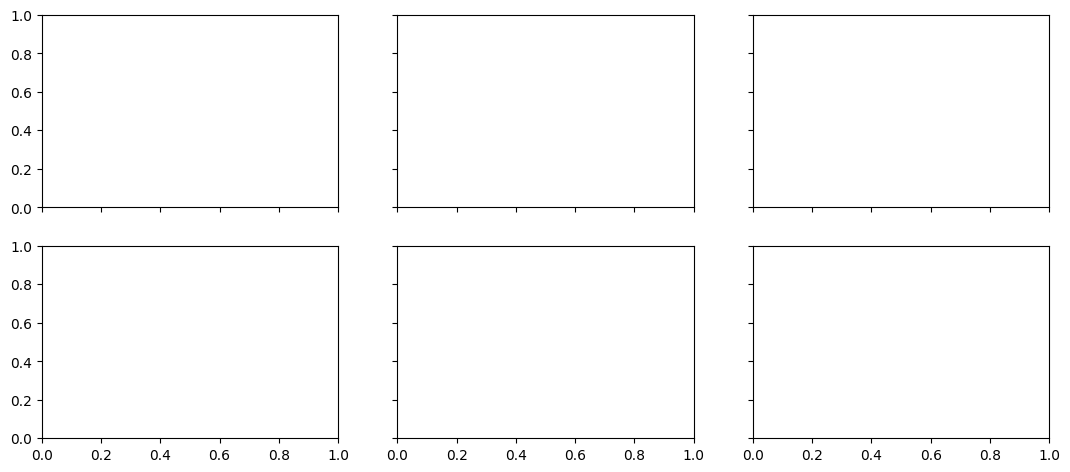

In [ ]:
# Spectral rates paper fig. 1-style eigenfunction comparison:
# - 3 columns = good / bad / ugly kernels
# - overlay PCR (blue) and RRR (orange)
# - show mean estimated eigenfunction across trials for the first few modes

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from tqdm import tqdm

# -----------------------------
# Parameters
# -----------------------------
kernels = ["good", "bad", "ugly"]
methods = [("PCR", False), ("RRR", True)]

n_train = 2000
subsample = 100
n_steps = n_train * subsample
n_trials = 50  # increase toward paper settings for smoother curves
n_show = 6  # number of leading eigenfunctions to plot
r = n_show
M = 10  # kernel truncation level
dt = 1e-4
lag = dt * subsample  # now consistent with how `data` was actually generated
n_components = 5
true_eigs = compute_ou_eig(gamma, lag, n_show)

x_plot = x.reshape(-1)


# -----------------------------
# Fit model and return eigenvalues
# -----------------------------
def fit_and_estimate_values(reduced_rank, x, density, random_state, kind, r, M, n_show):
    out = np.full(n_show, np.nan, dtype=float)

    try:
        data = simulate_ou(n_steps=n_steps, gamma=gamma, dt=dt, random_state=0, x0=0.0)
        data = data.iloc[::subsample]
        data = data[:n_train]

        model = KernelRidge(
            n_components=n_show,
            reduced_rank=reduced_rank,
            kernel=hermite_kernel(kind, r, M),
            alpha=1e-8,
            random_state=random_state,
        )

        model.fit(data)
        values, functions = model.eig(eval_right_on=x)

        values = np.asarray(values)
        values = np.real_if_close(values)

        if values.ndim == 0:
            values = np.array([values])

        # keep only approximately real eigenvalues
        real_mask = np.abs(np.imag(values)) < 1e-8
        values = np.real(values[real_mask])

        # keep only finite values
        values = values[np.isfinite(values)]

        # exclude values slightly above 1 from numerical noise
        values = values[values <= 1.0 + 1e-8]

        # sort by value, largest first
        values = np.sort(values)[::-1]

        k = min(n_show, values.size)
        out[:k] = values[:k]

    except Exception:
        pass

    return out


# -----------------------------
# Collect spectra
# -----------------------------
results = defaultdict(list)

for kind in kernels:
    for method, reduced_rank in methods:
        for trial in tqdm(range(n_trials), desc=f"{kind}-{method}"):
            vals = fit_and_estimate_values(
                reduced_rank=reduced_rank,
                x=x,
                density=density,
                random_state=trial,
                kind=kind,
                r=r,
                M=M,
                n_show=n_show,
            )
            results[(kind, method)].append(np.asarray(vals, dtype=float))


for key, arr_list in results.items():
    arr = np.stack(arr_list, axis=0)
    valid_cols = np.any(np.isfinite(arr), axis=0)
    mean_vals = np.full(arr.shape[1], np.nan)
    mean_vals[valid_cols] = np.nanmean(arr[:, valid_cols], axis=0)
    print(key, mean_vals)

# -----------------------------
# Plot
# -----------------------------
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13.0, 5.5),
    sharex=True,
    sharey=True,
)

colors = {"PCR": "tab:blue", "RRR": "tab:orange"}
bins = np.linspace(-0.02, 1.02, 80)

for row, (method, _) in enumerate(methods):
    for col, kind in enumerate(kernels):
        ax = axs[row, col]

        vals = np.stack(results[(kind, method)], axis=0)  # shape (n_trials, n_show)

        for m in range(n_show):
            vm = vals[:, m]
            vm = vm[np.isfinite(vm)]

            if vm.size == 0:
                continue

            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="stepfilled",
                alpha=0.22,
                color=colors[method],
            )
            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="step",
                lw=1.3,
                color=colors[method],
            )

        for ev in true_eigs:
            ax.axvline(float(ev), color="black", ls="--", lw=1.0, alpha=0.8)

        ax.set_title(f"{method} / {kind}", fontsize=12)
        ax.set_xlim(-0.02, 1.02)
        ax.grid(alpha=0.20)

        if col == 0:
            ax.set_ylabel("Density")

for ax in axs[-1, :]:
    ax.set_xlabel("Estimated eigenvalue")

# compact legend

legend_handles = [
    Patch(facecolor="tab:blue", edgecolor="tab:blue", alpha=0.22, label="PCR distribution"),
    Patch(facecolor="tab:orange", edgecolor="tab:orange", alpha=0.22, label="RRR distribution"),
    Line2D([0], [0], color="black", lw=1.0, ls="--", label="True Koopman eigenvalue"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "OU spectrum under good, bad, and ugly kernels",
    fontsize=14,
    y=1.06,
)

plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# Plot
# -----------------------------

# Compute one x-range per kernel, shared across PCR/RRR rows in that column
kernel_ranges = {}
for kind in kernels:
    combined = []
    for method, _ in methods:
        arr = np.asarray(results[(kind, method)], dtype=float)
        combined.append(arr[np.isfinite(arr)])
    combined = np.concatenate(combined)

    if combined.size == 0:
        kernel_ranges[kind] = (0.0, 1.0)
        continue

    if kind in ("good", "bad"):
        xlo = min(0.965, np.nanmin(combined) - 0.002)
        xhi = max(1.002, np.nanmax(combined) + 0.002)
    else:
        span = np.nanmax(combined) - np.nanmin(combined)
        pad = max(0.03, 0.08 * span if span > 0 else 0.05)
        xlo = np.nanmin(combined) - pad
        xhi = np.nanmax(combined) + pad

    kernel_ranges[kind] = (xlo, xhi)

fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13.5, 5.8),
    sharex=False,
    sharey=False,
)

mode_colors = ["tab:blue", "tab:orange", "tab:green"]

for row, (method, _) in enumerate(methods):
    for col, kind in enumerate(kernels):
        ax = axs[row, col]
        vals = np.asarray(results[(kind, method)], dtype=float)  # shape (n_trials, n_show)

        xlo, xhi = kernel_ranges[kind]
        bins = np.linspace(xlo, xhi, 60)
    
        # plot mode-wise empirical distributions
        for m in range(min(n_show, vals.shape[1])):
            vm = vals[:, m]
            vm = vm[np.isfinite(vm)]
            if vm.size == 0:
                continue

            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="step",
                lw=1.8,
                color=mode_colors[m % len(mode_colors)],
                label=f"Mode {m + 1}" if (row == 0 and col == 0) else None,
            )

        # true Koopman eigenvalue lines, only if visible in this panel
        for j, ev in enumerate(true_eigs[:n_show]):
            if xlo <= ev <= xhi:
                ax.axvline(
                    float(ev),
                    color="black",
                    ls="--",
                    lw=1.0,
                    alpha=0.8,
                    label="True Koopman eigenvalue" if (row == 0 and col == 0 and j == 0) else None,
                )

        ax.set_title(f"{method} / {kind}", fontsize=12)
        ax.set_xlim(xlo, xhi)
        ax.grid(alpha=0.20)

        if col == 0:
            ax.set_ylabel("Density")
        if row == len(methods) - 1:
            ax.set_xlabel("Estimated eigenvalue")

legend_handles = [
    Line2D([0], [0], color="tab:blue", lw=1.8, label="Mode 1"),
    Line2D([0], [0], color="tab:orange", lw=1.8, label="Mode 2"),
    Line2D([0], [0], color="tab:green", lw=1.8, label="Mode 3"),
    Line2D([0], [0], color="black", lw=1.0, ls="--", label="True Koopman eigenvalue"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.03),
)

fig.suptitle(
    "OU spectrum under good, bad, and ugly kernels",
    fontsize=14,
    y=1.08,
)

plt.tight_layout()
plt.show()


fig.suptitle(
    "OU spectrum under good, bad, and ugly kernels",
    fontsize=14,
    y=1.08,
)

plt.tight_layout()
plt.show()


AttributeError: module 'numpy' has no attribute 'trapz'